# mlops
## the questions that are needed to ask for the deployment
* what is my most ideal ml model deployment scenarion(works everytime with speed of light)
* where is my model goint to go?(on device and cloud)
* how is my model going to fuction?(online real time and offline batch)

In [2]:
# the dataset we are gonna use for the forr vision mini model is pizza steak shushi 20%
import torch
import torchvision
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
from pathlib import Path
data_20_percent_path=Path("data/pizza_steak_sushi_20_percent")
data_20_percent_path

WindowsPath('data/pizza_steak_sushi_20_percent')

In [4]:
#setup training and test paths
train_dir=data_20_percent_path/"train"
test_dir=data_20_percent_path/"test"
train_dir,test_dir

(WindowsPath('data/pizza_steak_sushi_20_percent/train'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test'))

we are going to train two model effecientnetb2 and vit feature extractor and compare their accuracy and latency before deployment

In [5]:
#creating effnetb2 feature extractor
import torchvision
#pretrained weight(transfer the learnings)
effnetb2_weights=torchvision.models.EfficientNet_B2_Weights.DEFAULT

#get effnetb2 transofrmer
effnetb2_transforms=effnetb2_weights.transforms()

#setup pretrained model instance
effnetb2=torchvision.models.efficientnet_b2(weights=effnetb2_weights)

#freeze the base layer in the model(this wil stop all layers from training)
for param in effnetb2.parameters():
    param.requires_grad=False

In [6]:
from torchinfo import summary
summary(model=effnetb2,
        input_size=(1,3,224,224),
        col_names=["input_size","output_size","num_params","trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   False
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 16,

In [7]:
effnetb2.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1408, out_features=1000, bias=True)
)

In [8]:
#set
from helper_functions import set_seeds
from torch import nn
set_seeds()
effnetb2.classifier=nn.Sequential(
    nn.Dropout(p=0.3,inplace=True),
    nn.Linear(in_features=1408,out_features=3,bias=True)
)

In [9]:
from torchinfo import summary
summary(model=effnetb2,
        input_size=(1,3,224,224),
        col_names=["input_size","output_size","num_params","trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

In [10]:
#creating the fuction for making the effnetb2 feature extractor
import torchvision
import torch
from torch import nn
def create_effnetb2_model(num_classes:int=3,
                          seed:int=42):
   
    #pretrained weight(transfer the learnings)
    weights=torchvision.models.EfficientNet_B2_Weights.DEFAULT

    #get effnetb2 transofrmer
    transforms=weights.transforms()

    #setup pretrained model instance
    model=torchvision.models.efficientnet_b2(weights=weights)

    #freeze the base layer in the model(this wil stop all layers from training)
    for param in model.parameters():
        param.requires_grad=False

    #change classifier head with random seed for reproducibility
    torch.manual_seed(seed)
    model.classifier=nn.Sequential(
        nn.Dropout(p=0.3,inplace=True),
        nn.Linear(in_features=1408,out_features=num_classes)
    )
    return model,transforms

In [11]:
effnetb2,effnetb2_transforms=create_effnetb2_model(num_classes=3,seed=42)

In [12]:
effnetb2_transforms

ImageClassification(
    crop_size=[288]
    resize_size=[288]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [13]:
from torchinfo import summary
summary(model=effnetb2,
        input_size=(1,3,224,224),
        col_names=["input_size","output_size","num_params","trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

In [14]:
#creating dataloaders for effnetb2
from going_modular import data_setup
train_dataloader_effnetb2,test_dataloader_effnetb2,class_names=data_setup.create_dataloaders(train_dir=train_dir,
                                                                                             test_dir=test_dir,
                                                                                             transform=effnetb2_transforms,
                                                                                             batch_size=32)

In [15]:
len(train_dataloader_effnetb2),len(test_dataloader_effnetb2),class_names

(15, 5, ['pizza', 'steak', 'sushi'])

In [16]:
#training the effnetb2 feature extractor
from going_modular import engine
#loss fun
loss_fn=torch.nn.CrossEntropyLoss()

#optimizer
optimizer=torch.optim.Adam(params=effnetb2.parameters(),
                           lr=1e-3)

#training function 
set_seeds()
effnetb2_results=engine.train(model=effnetb2,
                              train_dataloader=train_dataloader_effnetb2,
                              test_dataloader=test_dataloader_effnetb2,
                              epochs=10,#no of epochs taken from the 8_experiment_tracking
                              optimizer=optimizer,
                              loss_fn=loss_fn,
                              device=device)


C:\Users\Priyanshu\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 10%|█         | 1/10 [00:06<00:55,  6.11s/it]

Epoch: 1 | train_loss: 0.9832 | train_acc: 0.5750 | test_loss: 0.7411 | test_acc: 0.9409


 20%|██        | 2/10 [00:11<00:47,  5.90s/it]

Epoch: 2 | train_loss: 0.7182 | train_acc: 0.8479 | test_loss: 0.5867 | test_acc: 0.9347


 30%|███       | 3/10 [00:17<00:40,  5.81s/it]

...

Epoch: 8 | train_loss: 0.3817 | train_acc: 0.9042 | test_loss: 0.3440 | test_acc: 0.9352


 90%|█████████ | 9/10 [00:50<00:05,  5.53s/it]

Epoch: 9 | train_loss: 0.3740 | train_acc: 0.8833 | test_loss: 0.3111 | test_acc: 0.9256


100%|██████████| 10/10 [00:56<00:00,  5.61s/it]

Epoch: 10 | train_loss: 0.3710 | train_acc: 0.8625 | test_loss: 0.2805 | test_acc: 0.9625


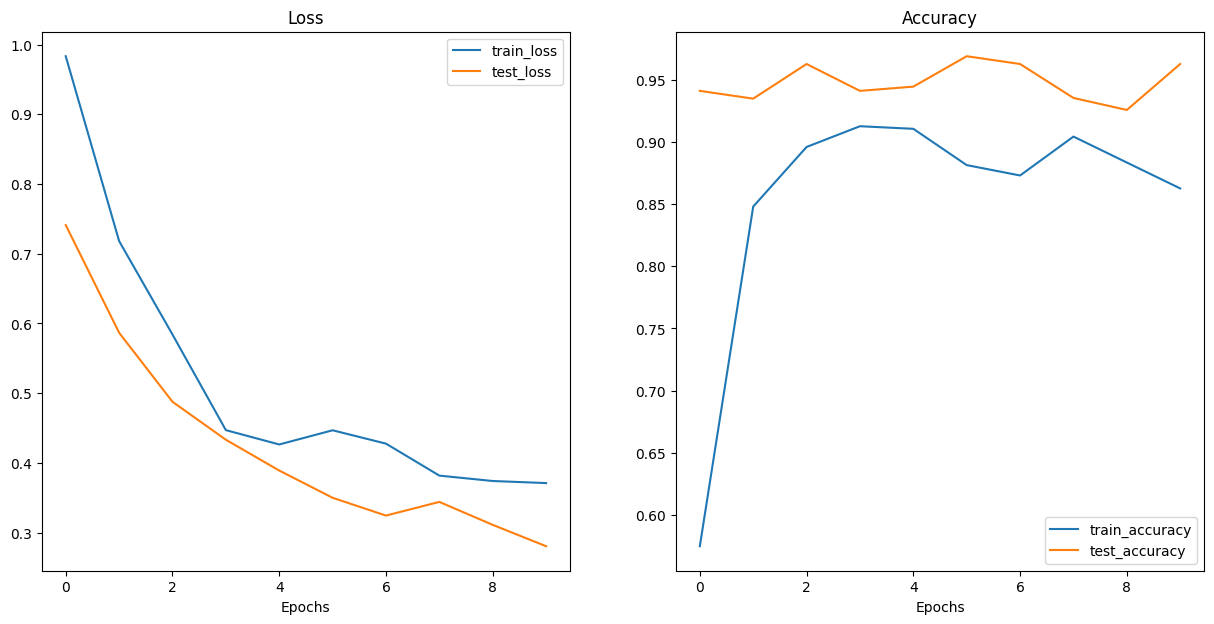

In [17]:
#visulainzing the loss curve
from going_modular.helper_functions import plot_loss_curves
plot_loss_curves(effnetb2_results)

In [18]:
# saving effnetb2 feature extractor
from going_modular import utils

utils.save_model(model=effnetb2,
                 target_dir="models",
                 model_name="10_pretrained_effnetb2_feature_extractor_pizza_stea_sushi_20_percent.pth")


[INFO] Saving model to: models\10_pretrained_effnetb2_feature_extractor_pizza_stea_sushi_20_percent.pth


In [19]:
#size of the model
from pathlib import Path

pretrained_effnetb2_model_size=Path("models/10_pretrained_effnetb2_feature_extractor_pizza_stea_sushi_20_percent.pth").stat().st_size/(1024*1024)
print(f"The size of the pretrained effnet model is :{round(pretrained_effnetb2_model_size,2)} MB")

The size of the pretrained effnet model is :29.86 MB


In [20]:
#count number of parameters in effnetb2
effnetb2_total_params=sum(torch.numel(param) for param in effnetb2.parameters())

effnetb2_total_params

7705221

In [21]:
#creating a dictionary with effnetb2 statistics
effnetb2_stat={"test_loss":effnetb2_results["test_loss"][-1],
               "test_acc":effnetb2_results["test_acc"][-1],
               "number_of_parameters":effnetb2_total_params,
               "model_size(MB)":pretrained_effnetb2_model_size}
effnetb2_stat

{'test_loss': 0.2804704368114471,
 'test_acc': 0.9625,
 'number_of_parameters': 7705221,
 'model_size(MB)': 29.864014625549316}

In [22]:
#creating vit feature extractor
vit=torchvision.models.vit_b_16()
vit.heads

Sequential(
  (head): Linear(in_features=768, out_features=1000, bias=True)
)

In [23]:
vit

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [24]:
def create_vit_model(num_classes:int=3,
                     seed:int=42):
    weights=torchvision.models.ViT_B_16_Weights.DEFAULT
    transforms=weights.transforms()
    model=torchvision.models.vit_b_16(weights=weights)

    #freeze all of the base layers
    for param in model.parameters():
        param.requires_grad=False
    
    #change classifier head to take the output as 3 classes or however it suits
    torch.manual_seed(seed)
    model.heads=nn.Sequential(nn.Linear(in_features=768,
                                        out_features=num_classes))
    return model,transforms

In [25]:
vit,vit_transforms=create_vit_model()
vit_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [26]:
from torchinfo import summary
summary(model=vit,
        input_size=(1,3,224,224),
        col_names=["input_size","output_size","num_params","trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224]     [1, 3]               768                  Partial
├─Conv2d (conv_proj)                                         [1, 3, 224, 224]     [1, 768, 14, 14]     (590,592)            False
├─Encoder (encoder)                                          [1, 197, 768]        [1, 197, 768]        151,296              False
│    └─Dropout (dropout)                                     [1, 197, 768]        [1, 197, 768]        --                   --
│    └─Sequential (layers)                                   [1, 197, 768]        [1, 197, 768]        --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 768]        [1, 197, 768]        (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 768]        [1, 1

In [27]:
#creating dataloader for vit feature extractor
from going_modular import data_setup
train_dataloader_vit,test_dataloader_vit,class_names=data_setup.create_dataloaders(train_dir=train_dir,
                                                                                   test_dir=test_dir,
                                                                                   transform=vit_transforms,
                                                                                   batch_size=32)
len(train_dataloader_vit),len(test_dataloader_vit),class_names

(15, 5, ['pizza', 'steak', 'sushi'])

In [28]:
#training the vit feature extractor
from going_modular import engine

optimizer=torch.optim.Adam(params=vit.parameters(),
                           lr=1e-3)

loss_fn=torch.nn.CrossEntropyLoss()

set_seeds()

vit_results=engine.train(model=vit,
                        train_dataloader=train_dataloader_vit,
                        test_dataloader=test_dataloader_vit,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=10,
                        device=device)

 10%|█         | 1/10 [00:13<01:58, 13.15s/it]

Epoch: 1 | train_loss: 0.7020 | train_acc: 0.7521 | test_loss: 0.2714 | test_acc: 0.9381


 20%|██        | 2/10 [00:26<01:44, 13.03s/it]

Epoch: 2 | train_loss: 0.2532 | train_acc: 0.9062 | test_loss: 0.1672 | test_acc: 0.9602


 30%|███       | 3/10 [00:38<01:30, 12.93s/it]

...

Epoch: 8 | train_loss: 0.0919 | train_acc: 0.9812 | test_loss: 0.0764 | test_acc: 0.9722


 90%|█████████ | 9/10 [01:56<00:12, 12.97s/it]

Epoch: 9 | train_loss: 0.0922 | train_acc: 0.9792 | test_loss: 0.0734 | test_acc: 0.9784


100%|██████████| 10/10 [02:08<00:00, 12.86s/it]

Epoch: 10 | train_loss: 0.0658 | train_acc: 0.9833 | test_loss: 0.0644 | test_acc: 0.9847


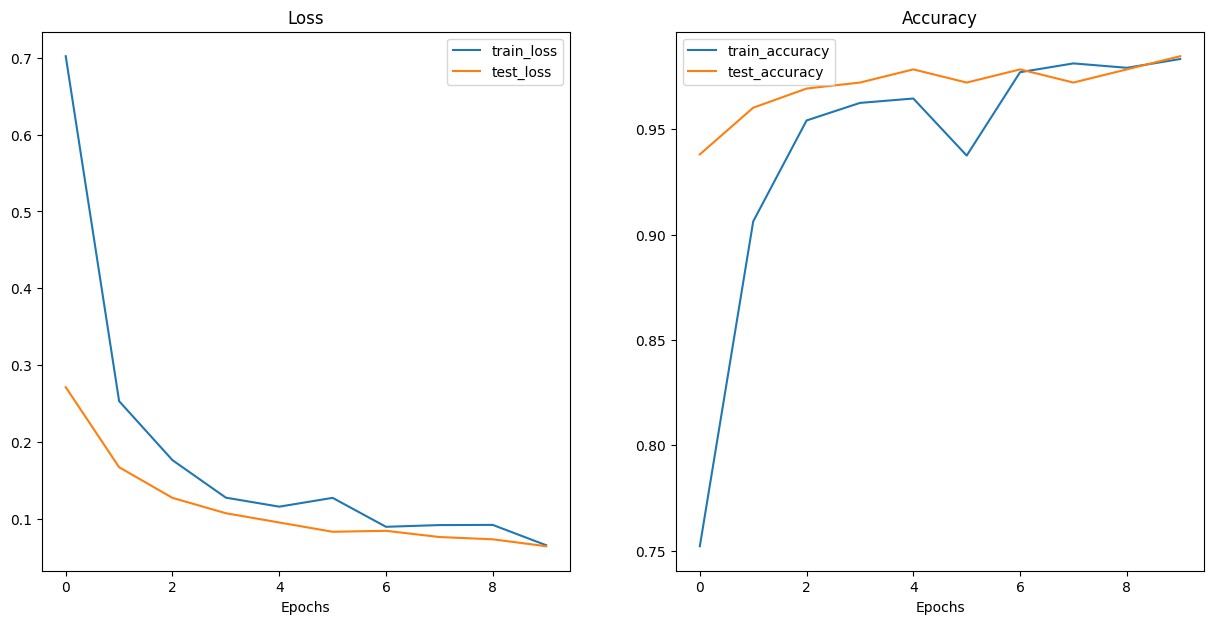

In [29]:
plot_loss_curves(vit_results)

In [30]:
#saving the vit feature extractor
from going_modular import utils
utils.save_model(model=vit,
                 target_dir="models",
                 model_name="10_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth")

[INFO] Saving model to: models\10_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth


In [31]:
#size of the model
from pathlib import Path

pretrained_vit_model_size=Path("models/10_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth").stat().st_size/(1024*1024)
print(f"The size of the pretrained vit model is :{round(pretrained_vit_model_size,2)} MB")

The size of the pretrained vit model is :327.37 MB


In [32]:
pretrained_effnetb2_model_size

29.864014625549316

In [33]:
#creating a dictionary with vit statistics
vit_total_params=sum(torch.numel(param)  for param in vit.parameters())
vit_stat={"test_loss":vit_results["test_loss"][-1],
        "test_acc":vit_results["test_acc"][-1],
        "number_of_parameters":vit_total_params,
        "model_size(MB)":pretrained_vit_model_size}
vit_stat

{'test_loss': 0.06443452099338173,
 'test_acc': 0.984659090909091,
 'number_of_parameters': 85800963,
 'model_size(MB)': 327.3715181350708}

In [34]:
effnetb2_stat

{'test_loss': 0.2804704368114471,
 'test_acc': 0.9625,
 'number_of_parameters': 7705221,
 'model_size(MB)': 29.864014625549316}

In [35]:
#making prediction with our trained models and time them (latency)
from pathlib import Path

#get all testdata paths
test_data_paths=list(Path(test_dir).glob("*/*.jpg"))
test_data_paths[:5]

[WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1001116.jpg'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1032754.jpg'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1067986.jpg'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/129666.jpg'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1315645.jpg')]

In [36]:
#creating the function to predictions accross testdataset
import pathlib
import torch

from PIL import Image
from timeit import default_timer as timer
from tqdm.auto import tqdm
from typing import List,Dict
#create a function that takes a list of paths
def pred_and_store(paths: List[pathlib.Path],
                  model:torch.nn.Module,
                  transform:torchvision.transforms,
                  class_names: List[str],
                  device: str="cuda" if torch.cuda.is_available() else "cpu")->List[Dict]:
    #create an empty list,to return the full list of all predictions later
    pred_list=[]

    #loop through the targe input paths 
    for path in tqdm(paths):
        #create an empty dict, for each sample
        pred_dict={}
        #get sample path and ground truth class form the filepath
        pred_dict["image_path"]=path
        class_name=path.parent.stem
        # print(class_name)
        pred_dict["class_name"]=class_name

        #start the prediction timer
        start_timer=timer()
        #opent the image using PIL.Image.open(path)
        img=Image.open(path)

        #transform the image to be usable with the given model(also add the batch dimension)
        transformed_image=transform(img).unsqueeze(0).to(device)

        #prepare the model for inference by sending to the targe device and turning on eval()mode
        model=model.to(device)
        model.eval()

        with torch.inference_mode():
            pred_logit=model(transformed_image)
            pred_prob=torch.softmax(pred_logit,dim=1)
            pred_label=torch.argmax(pred_prob,dim=1)
            pred_class=class_names[pred_label.cpu()]

            #add the pred prob_pred class to empty dictionary
            pred_dict["pred_prob"]=round(pred_prob.unsqueeze(0).max().cpu().item(),4)
            pred_dict["pred_class"]=pred_class

            #end the prediction timer
            end_timer=timer()
            pred_dict["time_for_pred"] = round(end_timer-start_timer,4)

            #see if the predicted class matches the gound truth class
            pred_dict["correct"] = class_name==pred_class

            #append the prediction dixtionay to the empty list of predictions
            pred_list.append(pred_dict)
    return pred_list






In [37]:
class_names,device

(['pizza', 'steak', 'sushi'], 'cuda')

In [38]:
#making an timing prediction for effnetb2
effnetb2_test_pred_dicts=pred_and_store(paths=test_data_paths,
                                        model=effnetb2,
                                        transform=effnetb2_transforms,
                                        class_names=class_names,
                                        device="cpu")


100%|██████████| 150/150 [00:10<00:00, 14.12it/s]


In [39]:
effnetb2_test_pred_dicts[:2]

[{'image_path': WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1001116.jpg'),
  'class_name': 'pizza',
  'pred_prob': 0.9941,
  'pred_class': 'pizza',
  'time_for_pred': 0.1185,
  'correct': True},
 {'image_path': WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1032754.jpg'),
  'class_name': 'pizza',
  'pred_prob': 0.4664,
  'pred_class': 'pizza',
  'time_for_pred': 0.084,
  'correct': True}]

In [40]:
#turn the test_pred_dicts into a dataframe
import pandas as pd
effnetb2_test_pred_df=pd.DataFrame(effnetb2_test_pred_dicts)
effnetb2_test_pred_df.head()

,image_path,class_name,pred_prob,pred_class,time_for_pred,correct
0,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.9941,pizza,0.1185,True
1,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.4664,pizza,0.0840,True
2,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.9920,pizza,0.0703,True
3,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.7002,pizza,0.0734,True
4,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.7605,pizza,0.0714,True


In [41]:
effnetb2_test_pred_df.shape

(150, 6)

In [42]:
effnetb2_test_pred_df.correct.value_counts()

correct
True     144
False      6
Name: count, dtype: int64

In [43]:
effnetb2_average_time_per_pred=round(effnetb2_test_pred_df.time_for_pred.mean(),4)
print(f"effnetb2 average time per prediction : {effnetb2_average_time_per_pred} sec")

effnetb2 average time per prediction : 0.0702 sec


In [44]:
#adding average time per prediction to effnet stats
effnetb2_stat["time_per_pred_cpu"]=float(effnetb2_average_time_per_pred)

In [45]:
#making and timing prediction with vit
vit_test_pred_dicts=pred_and_store(paths=test_data_paths,
                                        model=vit,
                                        transform=vit_transforms,
                                        class_names=class_names,
                                        device="cpu")


100%|██████████| 150/150 [00:21<00:00,  7.05it/s]


In [46]:
vit_test_pred_dicts[:2]

[{'image_path': WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1001116.jpg'),
  'class_name': 'pizza',
  'pred_prob': 0.9987,
  'pred_class': 'pizza',
  'time_for_pred': 0.3853,
  'correct': True},
 {'image_path': WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1032754.jpg'),
  'class_name': 'pizza',
  'pred_prob': 0.9957,
  'pred_class': 'pizza',
  'time_for_pred': 0.1507,
  'correct': True}]

In [47]:
import pandas as pd
vit_test_pred_df=pd.DataFrame(vit_test_pred_dicts)
vit_test_pred_df.head()

,image_path,class_name,pred_prob,pred_class,time_for_pred,correct
0,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.9987,pizza,0.3853,True
1,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.9957,pizza,0.1507,True
2,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.9987,pizza,0.1416,True
3,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.9869,pizza,0.1435,True
4,data\pizza_steak_sushi_20_percent\test\pizza\1...,pizza,0.9698,pizza,0.1481,True


In [48]:
vit_test_pred_df.correct.value_counts()

correct
True     148
False      2
Name: count, dtype: int64

In [49]:
#calculate average time per prediction for vit model
vit_average_time_per_pred=round(vit_test_pred_df.time_for_pred.mean(),4)
print(f"effnetb2 average time per prediction : {vit_average_time_per_pred} sec")

effnetb2 average time per prediction : 0.1407 sec


In [50]:
#adding average time per prediction to vit stats
vit_stat["time_per_pred_cpu"]=float(vit_average_time_per_pred)


In [51]:
vit_stat

{'test_loss': 0.06443452099338173,
 'test_acc': 0.984659090909091,
 'number_of_parameters': 85800963,
 'model_size(MB)': 327.3715181350708,
 'time_per_pred_cpu': 0.1407}

In [52]:
effnetb2_stat

{'test_loss': 0.2804704368114471,
 'test_acc': 0.9625,
 'number_of_parameters': 7705221,
 'model_size(MB)': 29.864014625549316,
 'time_per_pred_cpu': 0.0702}

In [53]:
#comparing the results 
df=pd.DataFrame([effnetb2_stat,vit_stat])
df["model"]=["EffnetB2","ViT"]
df["test_acc"]=round(df["test_acc"]*100,2)
df

,test_loss,test_acc,number_of_parameters,model_size(MB),time_per_pred_cpu,model
0,0.280470,96.25,7705221,29.864015,0.0702,EffnetB2
1,0.064435,98.47,85800963,327.371518,0.1407,ViT


In [54]:
#in the perfomance the ViT model is better (test loss,test acc)
#but in other like effeciency the storage of vit is much high and also same for the model size and time per pred cpu
pd.DataFrame(data=(df.set_index("model").loc["ViT"]/df.set_index("model").loc["EffnetB2"]),
             columns=["vit to effnet ratios"]).T

,test_loss,test_acc,number_of_parameters,model_size(MB),time_per_pred_cpu
vit to effnet ratios,0.229737,1.023065,11.135432,10.962073,2.004274


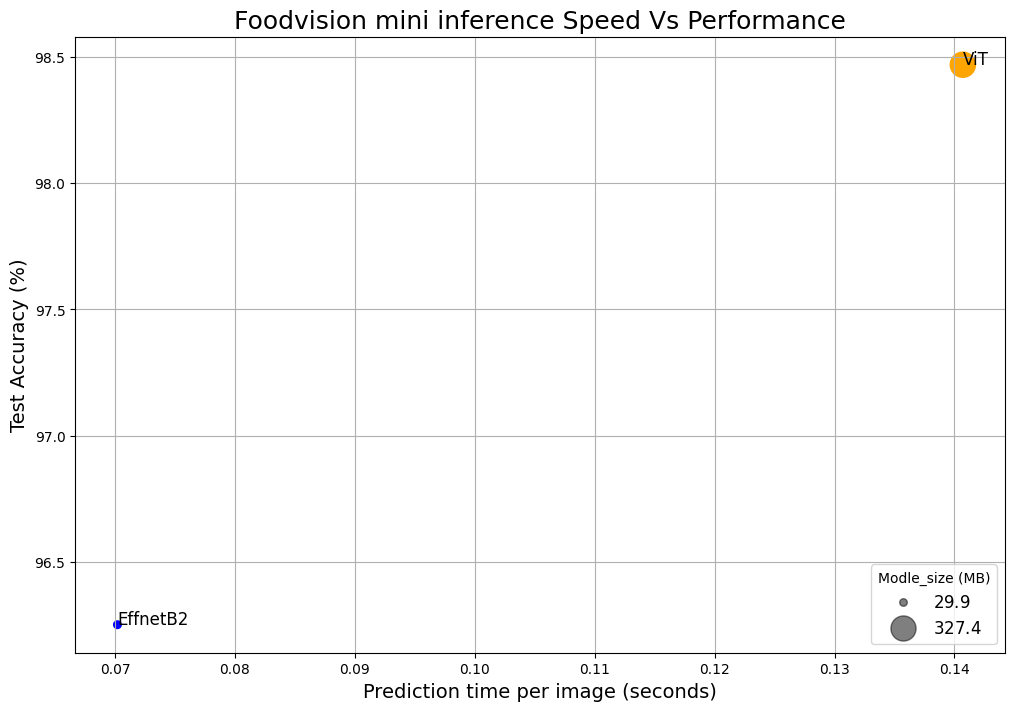

In [55]:
#visualizing the speed vs performance tradeoff
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(12,8))
scatter=ax.scatter(data=df,
                   x="time_per_pred_cpu",
                   y="test_acc",
                   c=["blue","orange"],
                   s="model_size(MB)")

#add titles and labels
ax.set_title("Foodvision mini inference Speed Vs Performance",fontsize=18)
ax.set_xlabel("Prediction time per image (seconds)",fontsize=14)
ax.set_ylabel("Test Accuracy (%)",fontsize=14)
ax.grid(True)

#annotate the samples on the scatter plot
for index,row in df.iterrows():
    ax.annotate(text=row["model"],
                xy=(row["time_per_pred_cpu"],row["test_acc"]),
                size=12)

#for the scatter element
handles,labels=scatter.legend_elements(prop="sizes",alpha=0.5)
model_size_legends=ax.legend(handles,labels,loc="lower right",title="Modle_size (MB)",fontsize=12)
plt.savefig("comparision_btw_speed_performance.png")

In [60]:
#bringing foodvision mini to life byb creating a gradiodemo
#so we are chosing effnetb2 model
#gradio helps to create a ml demos
#images of food->effentb2->output
#put out model to cpu because gradion only uses cpu for free ...gpu for paid
effnetb2=effnetb2.to("cpu")
next(iter(effnetb2.parameters())).device

device(type='cpu')

In [61]:
#lets create a function called predict to go from images of food to ml model effnetb2->outputs
from typing import Tuple,Dict
def predict(img)->Tuple[Dict,float]:
    #start a timer
    start_time=timer()
    #Transform the input image for use with effnetb2
    img=effnetb2_transforms(img).unsqueeze(0)#it add the batch dimension
    #put model into eval mode,make prediction
    effnetb2.eval()
    with torch.inference_mode():
        pred_probs=torch.softmax(effnetb2(img),dim=1)
    #create a prediction label and prediction probablity dectionary
    pred_labels_and_probs={class_names[i]:float(pred_probs[0][i])for i in range(len(class_names))}
    #calculate pred time 
    end_time=timer()
    pred_time=round(end_time-start_time,4)
    return pred_labels_and_probs,pred_time

In [67]:
import random
from PIL import Image

test_data_paths=list(Path(test_dir).glob("*/*.jpg"))
random_image_path=random.sample(test_data_paths,k=1)[0]
image=Image.open(random_image_path)
print(f"[INFO] predicting on image at path:{random_image_path}\n")
pred_dict,pred_time=predict(img=image)
print(pred_dict)
print(pred_time)

[INFO] predicting on image at path:data\pizza_steak_sushi_20_percent\test\sushi\2012780.jpg

{'pizza': 0.024238314479589462, 'steak': 0.11200696974992752, 'sushi': 0.8637547492980957}
0.0793


In [68]:
#create a list of example imputs to our gradio demo
example_list=[[str(filepath)]for filepath in random.sample(test_data_paths,k=3)]
example_list

[['data\\pizza_steak_sushi_20_percent\\test\\steak\\3873655.jpg'],
 ['data\\pizza_steak_sushi_20_percent\\test\\pizza\\796922.jpg'],
 ['data\\pizza_steak_sushi_20_percent\\test\\sushi\\2903125.jpg']]

In [74]:
import gradio as gr
#create a title description and an article
title="DISH-PREDICTOR"
description="it is an effecientnetb2 feature extractor computer vision model to classify images as pizza,steak or sushi."
article="create at :(https://github.com/Priyanshu-byte-coder/pytorch_learing)"

#create the gradio demo
demo=gr.Interface(fn=predict,
                  inputs=gr.Image(type="pil"),
                  outputs=[gr.Label(num_top_classes=3,label="Predictions"),
                           gr.Number(label="Prediction time(s)")],
                  examples=example_list,
                  title=title,
                  description=description,
                  article=article)
demo.launch(debug=False,
            share=True)

* Running on local URL:  http://127.0.0.1:7864

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.
